In [1]:
import pickle
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse
import shapely
import tqdm
import quadpy
from pathlib import Path
import warnings
from random_matrix.amplitude_matrix import (
    isotropic_sphere,
    scattering_geometry,
)
from random_matrix.input_statistics import density_function, density_integrals
from random_matrix.input_statistics.density_function import (
    DeltaDensityFactor,
    DensityFunction,
    DensityFunctionTerm,
    RegularDensityFactor,
)
from random_matrix.input_statistics.index_finder import IndexFinder
from random_matrix.input_statistics.input_statistics_manager import (
    InputStatisticsManager,
)
from random_matrix.input_statistics.integration_task import (
    IntegrationTaskPreparer,
    IntegrationTaskConfig,
)
from random_matrix.input_statistics.medium_parameters import MediumParameters
from random_matrix.input_statistics.medium_statistics import (
    MediumStatistics,
    ParticleStatistics,
)
from random_matrix.modes import mode_grid, mode_grid_factory
from random_matrix.utils import (
    array_utils,
    function_utils,
    geometry_utils,
    integration_utils,
    matrix_utils,
    special_functions,
)
from random_matrix.scattering_matrix import sampler

In [2]:
DATA_DIR_FILENAME = Path("/home/nbyrnes/code/random-matrix/paper_data/data")
MODE_GRIDS_FILENAME = Path(
    "/home/nbyrnes/code/random-matrix/paper_data/mode_grids_rectangular.pkl"
)
TWO_NP_PREAMBLE = "2d_np_rectangular_midpoint_"
THREE_NP_PREAMBLE = "3d_np_rectangular_midpoint_"
TWO_CP_PREAMBLE = "2d_cp_rectangular_midpoint_"
THREE_CP_PREAMBLE = "3d_cp_rectangular_midpoint_"

if MODE_GRIDS_FILENAME.exists():
    # Load existing mode grids
    with MODE_GRIDS_FILENAME.open("rb") as f:
        mode_grids = pickle.load(f)
        num_modes = [m.num_propagating for m in mode_grids]

two_np_paths = [
    DATA_DIR_FILENAME / f"{TWO_NP_PREAMBLE}{n}/integration_result_list.pkl"
    for n in num_modes
]
three_np_paths = [
    DATA_DIR_FILENAME / f"{THREE_NP_PREAMBLE}{n}/integration_result_list.pkl"
    for n in num_modes
]
two_cp_paths = [
    DATA_DIR_FILENAME / f"{TWO_CP_PREAMBLE}{n}/integration_result_list.pkl"
    for n in num_modes
]
three_cp_paths = [
    DATA_DIR_FILENAME / f"{THREE_CP_PREAMBLE}{n}/integration_result_list.pkl"
    for n in num_modes
]

two_np_results = []
three_np_results = []
two_cp_results = []
three_cp_results = []

for p in two_np_paths:
    if p.exists():
        with p.open("rb") as f:
            results = pickle.load(f)
            two_np_results.append(results)
for p in three_np_paths:
    if p.exists():
        with p.open("rb") as f:
            results = pickle.load(f)
            three_np_results.append(results)
for p in two_cp_paths:
    if p.exists():
        with p.open("rb") as f:
            results = pickle.load(f)
            two_cp_results.append(results)
for p in three_cp_paths:
    if p.exists():
        with p.open("rb") as f:
            results = pickle.load(f)
            three_cp_results.append(results)

### Mean

In [3]:
mean_results_two_np = [r.by_statistic_type("mean") for r in two_np_results]
mean_results_three_np = [r.by_statistic_type("mean") for r in three_np_results]
mean_results_two_cp = [r.by_statistic_type("mean") for r in two_cp_results]
mean_results_three_cp = [r.by_statistic_type("mean") for r in three_cp_results]

In [4]:
mean_results_two_np[0].results[0].block_location[1]

't'

In [5]:
def results_to_dict(results, block="t"):
    return {
        r.sub_block_locations[0]: r.integral
        for r in results
        if r.sub_block_locations and r.block_location[1] == block
    }


mean_two_np_t = [
    results_to_dict(result_list.results, "t")
    for result_list in mean_results_two_np
]
mean_two_np_r = [
    results_to_dict(result_list.results, "r")
    for result_list in mean_results_two_np
]
mean_two_np_r2 = [
    results_to_dict(result_list.results, "r2")
    for result_list in mean_results_two_np
]


mean_three_np_t = [
    results_to_dict(result_list.results, "t")
    for result_list in mean_results_three_np
]
mean_three_np_r = [
    results_to_dict(result_list.results, "r")
    for result_list in mean_results_three_np
]
mean_three_n_r2 = [
    results_to_dict(result_list.results, "r2")
    for result_list in mean_results_three_np
]

### Central mean

In [6]:
central_mean_two_np = [dic[0, 0].reshape(2, 2) for dic in mean_two_np_t]
central_mean_three_np = [dic[0, 0].reshape(3, 3) for dic in mean_three_np_t]

In [7]:
# Get the infinitesimal matrix (ground truth?)
wavelength = 550e-9
k = 2 * np.pi / wavelength
slab_thickness = 1.8992695221776513e-06
number_density = 5.921762640653617e17
medium_parameters = MediumParameters(
    wavelength=wavelength,
    number_density=number_density,
    slab_thickness=slab_thickness,
)
term = DensityFunctionTerm.from_delta({"x": 2.0, "m": 1.2})

A = (
    isotropic_sphere.get_A(
        np.array([0.0]),
        np.array([0.0]),
        np.array([1.0]),
        np.array([0.0]),
        np.array([0.0]),
        np.array([1.0]),
        np.array([2.0]),
        np.array([1.2]),
    )
    * medium_parameters.mean_const_factor
)
print(A.reshape(2, 2))
ground_truth = np.linalg.norm(A)
print(ground_truth)

[[0.0130462-0.06088037j 0.       +0.j        ]
 [0.       +0.j         0.0130462-0.06088037j]]
0.08805251317988078


/home/nbyrnes/code/random-matrix/random_matrix/amplitude_matrix/scattering_geometry.py:30: RuntimeWarning: invalid value encountered in divide
  e_phi /= mod_kappa[..., xp.newaxis]
/home/nbyrnes/code/random-matrix/random_matrix/amplitude_matrix/scattering_geometry.py:44: RuntimeWarning: invalid value encountered in divide
  e_theta /= xp.sqrt(


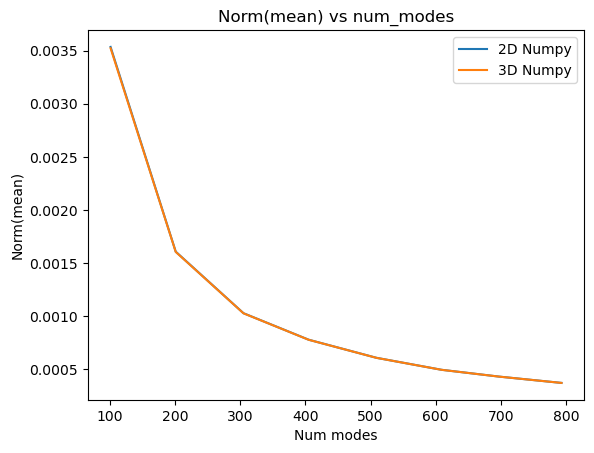

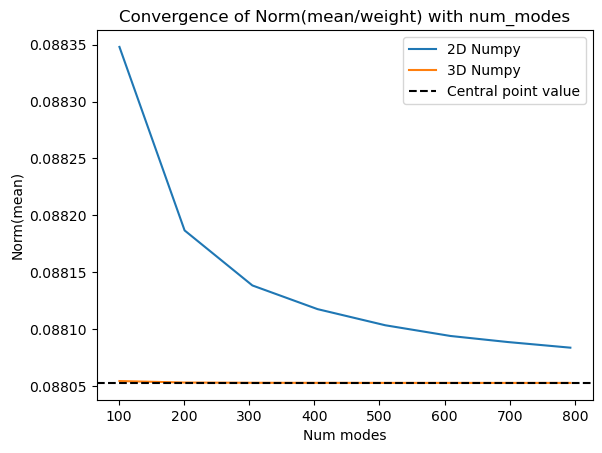

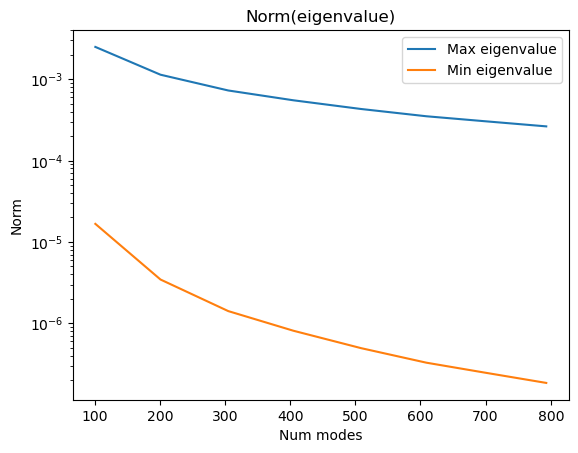

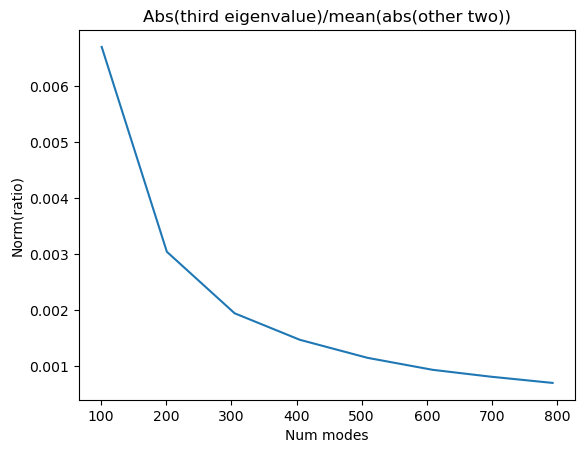

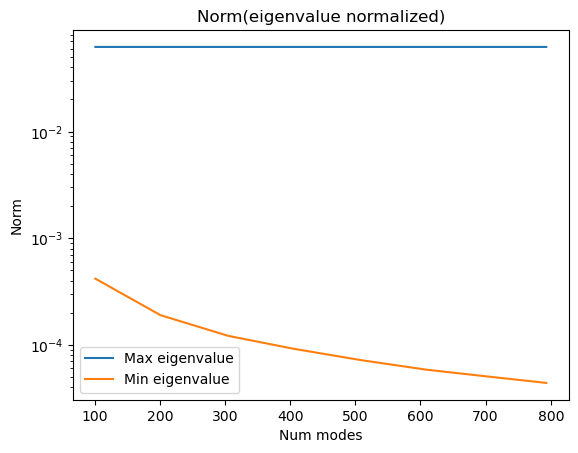

In [8]:
end_index_two = len(central_mean_two_np)
end_index_three = len(central_mean_three_np)

y1 = [np.linalg.norm(mean) for mean in central_mean_two_np]
y2 = [
    np.linalg.norm(mean / mode_grid.by_index(0).weight)
    for mean, mode_grid in zip(
        central_mean_two_np, mode_grids[0:end_index_two]
    )
]

y3 = [np.linalg.norm(mean) for mean in central_mean_three_np]
y4 = [
    np.linalg.norm(mean / mode_grid.by_index(0).weight)
    for mean, mode_grid in zip(
        central_mean_three_np, mode_grids[0:end_index_three]
    )
]


min_vals = [
    np.min(np.abs(np.linalg.eigvals(mat))) for mat in central_mean_three_np
]
max_vals = [
    np.max(np.abs(np.linalg.eigvals(mat))) for mat in central_mean_three_np
]
y5 = np.array(min_vals) / np.array(max_vals)

min_vals_normalized = [
    np.min(np.abs(np.linalg.eigvals(mat / mode_grid.by_index(0).weight)))
    for mat, mode_grid in zip(central_mean_three_np, mode_grids)
]
max_vals_normalized = [
    np.max(np.abs(np.linalg.eigvals(mat / mode_grid.by_index(0).weight)))
    for mat, mode_grid in zip(central_mean_three_np, mode_grids)
]
y6 = np.array(min_vals_normalized) / np.array(max_vals_normalized)


fig, ax = plt.subplots()
ax.plot(np.array(num_modes)[0:end_index_two], y1, label="2D Numpy")
ax.plot(np.array(num_modes)[0:end_index_three], y3, label="3D Numpy")
ax.set_ylabel("Norm(mean)")
ax.set_xlabel("Num modes")
ax.set_title("Norm(mean) vs num_modes")
ax.legend()

fig, ax = plt.subplots()
ax.plot(np.array(num_modes)[0:end_index_two], y2, label="2D Numpy")
ax.plot(np.array(num_modes)[0:end_index_three], y4, label="3D Numpy")
ax.axhline(
    y=ground_truth, color="black", linestyle="--", label="Central point value"
)
ax.set_ylabel("Norm(mean)")
ax.set_xlabel("Num modes")
ax.set_title("Convergence of Norm(mean/weight) with num_modes")
ax.legend()

fig, ax = plt.subplots()
ax.plot(
    np.array(num_modes)[0:end_index_three], max_vals, label="Max eigenvalue"
)
ax.plot(
    np.array(num_modes)[0:end_index_three], min_vals, label="Min eigenvalue"
)
ax.set_ylabel("Norm")
ax.set_xlabel("Num modes")
ax.set_yscale("log")
ax.set_title("Norm(eigenvalue)")
ax.legend()

fig, ax = plt.subplots()
ax.plot(np.array(num_modes)[0:end_index_three], y5, label="3D Numpy")
ax.set_ylabel("Norm(ratio)")
ax.set_xlabel("Num modes")
ax.set_title("Abs(third eigenvalue)/mean(abs(other two))")

fig, ax = plt.subplots()
ax.plot(
    np.array(num_modes)[0:end_index_three],
    max_vals_normalized,
    label="Max eigenvalue",
)
ax.plot(
    np.array(num_modes)[0:end_index_three],
    min_vals_normalized,
    label="Min eigenvalue",
)
ax.set_ylabel("Norm")
ax.set_xlabel("Num modes")
ax.set_yscale("log")
ax.set_title("Norm(eigenvalue normalized)")
ax.legend()

### Cross sections

In [9]:
# Real cross section
def mie_cross_section(x, m, k, N_lim=20):
    psi_x = scipy.special.riccati_jn(N_lim, x)
    psi_mx = scipy.special.riccati_jn(N_lim, m * x)
    phi_x = scipy.special.riccati_yn(N_lim, x)
    xi_x = [psi + 1j * phi for psi, phi in zip(psi_x, phi_x)]

    C_sca = 0
    C_ext = 0
    for n in range(1, N_lim):
        a = (m * psi_mx[0][n] * psi_x[1][n] - psi_x[0][n] * psi_mx[1][n]) / (
            m * psi_mx[0][n] * xi_x[1][n] - xi_x[0][n] * psi_mx[1][n]
        )
        b = (psi_mx[0][n] * psi_x[1][n] - m * psi_x[0][n] * psi_mx[1][n]) / (
            psi_mx[0][n] * xi_x[1][n] - m * xi_x[0][n] * psi_mx[1][n]
        )
        C_sca = C_sca + (2 * n + 1) * (
            np.absolute(a) ** 2 + np.absolute(b) ** 2
        )
        C_ext = C_ext + (2 * n + 1) * np.real(a + b)

    C_sca = 2 * np.pi * C_sca / k**2
    C_ext = 2 * np.pi * C_ext / k**2
    return C_sca, C_ext


cs = mie_cross_section(2,1.2,k,30)[0]
print(cs)

2.3199378748100525e-14


In [10]:
# Test
A =isotropic_sphere.get_A(
        np.array([0.0]),
        np.array([0.0]),
        np.array([1.0]),
        np.array([0.0]),
        np.array([0.0]),
        np.array([1.0]),
        np.array([2.0]),
        np.array([1.2]),
    ).reshape(2,2)
print(A*4*np.pi/k**2)
print(A)
print(A*medium_parameters.mean_const_factor)
print(np.linalg.norm((A*medium_parameters.mean_const_factor)))

[[2.31993787e-14-1.08260411e-13j 0.00000000e+00+0.00000000e+00j]
 [0.00000000e+00+0.00000000e+00j 2.31993787e-14-1.08260411e-13j]]
[[0.24093553-1.12433095j 0.        +0.j        ]
 [0.        +0.j         0.24093553-1.12433095j]]
[[0.0130462-0.06088037j 0.       +0.j        ]
 [0.       +0.j         0.0130462-0.06088037j]]
0.08805251317988078


In [11]:
factor = medium_parameters.mean_const_factor

data = mean_two_np_t[0]
w = mode_grids[0].by_index(0).weight
val = data[0,0]/w
print(val)
print(val/factor)
print(val/factor * 4*np.pi/k**2)


[[ 1.30899922e-02-6.10847368e-02j  0.00000000e+00+0.00000000e+00j
  -2.60897717e-37+3.98237892e-35j  1.30899922e-02-6.10847368e-02j]]
[[ 2.41744322e-01-1.12810520e+00j  0.00000000e+00+0.00000000e+00j
  -4.81822606e-36+7.35460707e-34j  2.41744322e-01-1.12810520e+00j]]
[[ 2.32772564e-14-1.08623829e-13j  0.00000000e+00+0.00000000e+00j
  -4.63940919e-49+7.08165852e-47j  2.32772564e-14-1.08623829e-13j]]


Text(0.5, 0.92, '2D')

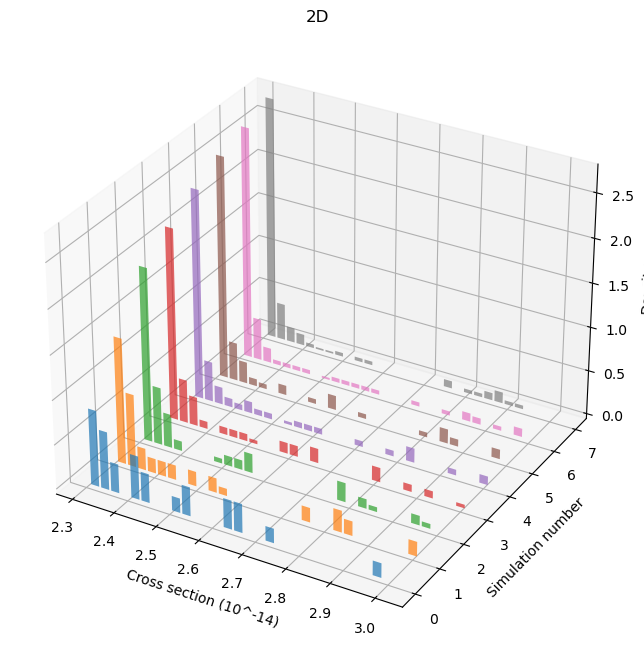

In [24]:
cs_list = []
for j in range(len(mean_two_np_t)):
    cs_list.append([])
    grid = mode_grids[j]
    mean_array = mean_two_np_t[j]
    for i in grid.propagating_indices:
        mode = grid.by_index(i)
        weight = mode.weight
        centroid = mode.center
        kappa_sq = centroid[0]**2 + centroid[1]**2
        kz = np.sqrt(1 - kappa_sq)
        mean = mean_array[i,i]
        modified = 4*np.pi * kz * mean / (weight*factor*k**2)
        new_cs = np.real(modified[0][0])
        cs_list[-1].append(new_cs)

fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

min_v = min(min(l) for l in cs_list)
max_v = max(max(l) for l in cs_list)

bins = np.linspace(min_v, max_v, 30)
for i, d in enumerate(cs_list):
    hist, edges = np.histogram(d, bins=bins, density=True)
    
    # X: bin centers, Y: offset for each histogram, Z: bar heights
    xs = (edges[:-1] + edges[1:]) / 2
    ys = np.full_like(xs, i)  # shift each histogram along y

    bin_width = edges[1] - edges[0]
    ax.bar(xs, hist, zs=i, zdir='y', width=0.8*bin_width, alpha=0.7)

ax.set_xlabel("Cross section (10^-14)")
ax.set_ylabel("Simulation number")
ax.set_zlabel("Density")
ax.set_title("2D")

Text(0.5, 0.92, '3D')

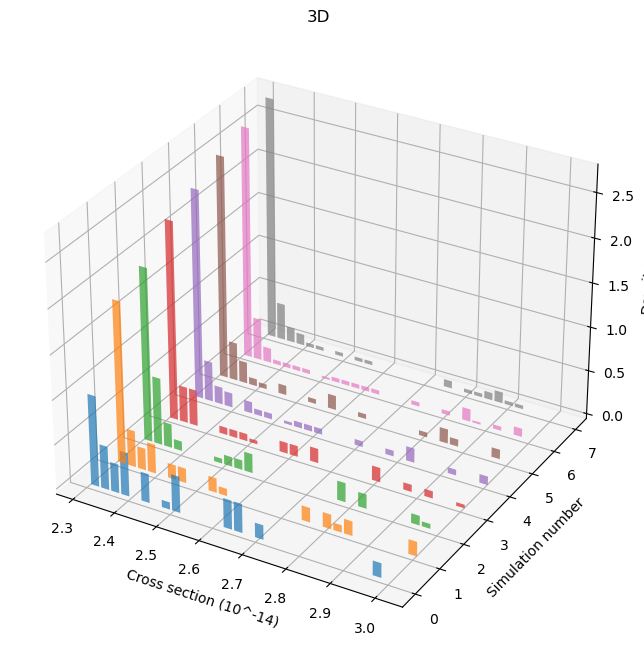

In [40]:
cs_list = []
for j in range(len(mean_three_np_t)):
    cs_list.append([])
    grid = mode_grids[j]
    mean_array = mean_three_np_t[j]
    for i in grid.propagating_indices:
        mode = grid.by_index(i)
        weight = mode.weight
        centroid = mode.center
        kappa_sq = centroid[0]**2 + centroid[1]**2
        kz = np.sqrt(1 - kappa_sq)
        mean = mean_array[i,i]
        modified = 4*np.pi * kz * mean / (weight*factor*k**2)

        eigs = np.linalg.eigvals(modified.reshape(3,3))
        new_cs = np.real(np.max(eigs))

        cs_list[-1].append(new_cs)

fig = plt.figure(figsize=(15,8))
ax = fig.add_subplot(111, projection='3d')

min_v = min(min(l) for l in cs_list)
max_v = max(max(l) for l in cs_list)

bins = np.linspace(min_v, max_v, 30)
for i, d in enumerate(cs_list):
    hist, edges = np.histogram(d, bins=bins, density=True)
    
    # X: bin centers, Y: offset for each histogram, Z: bar heights
    xs = (edges[:-1] + edges[1:]) / 2
    ys = np.full_like(xs, i)  # shift each histogram along y

    bin_width = edges[1] - edges[0]
    ax.bar(xs, hist, zs=i, zdir='y', width=0.8*bin_width, alpha=0.7)

ax.set_xlabel("Cross section (10^-14)")
ax.set_ylabel("Simulation number")
ax.set_zlabel("Density")
ax.set_title("3D")

In [39]:
print(mean_two_np_t[-1][5,5])
print(mean_three_np_t[-1][5,5])
eigs = np.linalg.eigvals(modified.reshape(3,3))
print(eigs)


[[ 2.47571333e-04-1.15529707e-03j -2.67711468e-38-2.10895987e-36j
  -4.67664230e-37-1.31117832e-36j  2.47571333e-04-1.15529707e-03j]]
[[ 1.14091835e-05-5.32412058e-05j -1.56293522e-05+7.29347160e-05j
   4.51177834e-05-2.10543129e-04j -1.56293522e-05+7.29347160e-05j
   2.46449106e-04-1.15006018e-03j  3.00408386e-06-1.40186234e-05j
   4.51177834e-05-2.10543129e-04j  3.00408386e-06-1.40186234e-05j
   2.37284376e-04-1.10729276e-03j]]
[2.31994678e-14-1.08260827e-13j 2.31994330e-14-1.08260665e-13j
 1.63790854e-17-7.64333625e-17j]


In [13]:
    hist, edges = np.histogram(cs_list[0], bins=bins)
    print(edges)
    xs = (edges[:-1] + edges[1:]) / 2
    ys = np.full_like(xs, i)  # shift each histogram along y
    print(ys)

[2.30967446e-14 2.33389271e-14 2.35811097e-14 2.38232922e-14
 2.40654747e-14 2.43076572e-14 2.45498397e-14 2.47920222e-14
 2.50342047e-14 2.52763873e-14 2.55185698e-14 2.57607523e-14
 2.60029348e-14 2.62451173e-14 2.64872998e-14 2.67294823e-14
 2.69716649e-14 2.72138474e-14 2.74560299e-14 2.76982124e-14
 2.79403949e-14 2.81825774e-14 2.84247599e-14 2.86669424e-14
 2.89091250e-14 2.91513075e-14 2.93934900e-14 2.96356725e-14
 2.98778550e-14 3.01200375e-14]
[7. 7. 7. 7. 7. 7. 7. 7. 7. 7. 7. 7. 7. 7. 7. 7. 7. 7. 7. 7. 7. 7. 7. 7.
 7. 7. 7. 7. 7.]


In [14]:
cs_list

[[2.328568867377413e-14,
  2.331937741350389e-14,
  2.342905822499371e-14,
  2.409506726981235e-14,
  2.7234769932409306e-14,
  2.644634237234858e-14,
  2.441491682438146e-14,
  2.3467005724972392e-14,
  2.3334489599708285e-14,
  2.3295353929751728e-14,
  2.328568867377413e-14,
  2.3295353953376155e-14,
  2.3334489789211172e-14,
  2.346700995770538e-14,
  2.441703411076934e-14,
  2.6446342372348623e-14,
  2.6574598270531182e-14,
  2.5285049882054238e-14,
  2.3654004448046505e-14,
  2.3398832102320165e-14,
  2.3334489599708304e-14,
  2.331937741350389e-14,
  2.3334489789211156e-14,
  2.3398833966221454e-14,
  2.365408065046346e-14,
  2.5285049882054216e-14,
  2.65745982705312e-14,
  2.4136769825330525e-14,
  2.506909246495005e-14,
  2.3654004448046505e-14,
  2.3467005724972385e-14,
  2.3429058224993682e-14,
  2.3467009957705363e-14,
  2.3654080650463444e-14,
  2.5109216974460807e-14,
  2.4136769825330377e-14,
  2.974250548251664e-14,
  2.413676982533052e-14,
  2.5285049882054203e-14,
  

### Central mode in reflection

In [15]:
print(mean_two_np_r[0][0, 0])
print(mean_two_np_t[0][0, 0])

[[-1.72256969e-06-1.06318814e-06j -1.47830277e-25+6.30081967e-26j
   1.47830277e-25-6.30081967e-26j  1.79263000e-06+1.03186007e-06j]]
[[ 5.23599689e-04-2.44338947e-03j  0.00000000e+00+0.00000000e+00j
  -1.04359087e-38+1.59295157e-36j  5.23599689e-04-2.44338947e-03j]]


In [16]:
central_mean_two_np = [dic[0, 0].reshape(2, 2) for dic in mean_two_np_r]
central_mean_three_np = [dic[0, 0].reshape(3, 3) for dic in mean_three_np_r]

In [17]:
# Get the infinitesimal matrix (ground truth?)
wavelength = 550e-9
k = 2 * np.pi / wavelength
slab_thickness = 1.8992695221776513e-06
number_density = 5.921762640653617e17
medium_parameters = MediumParameters(
    wavelength=wavelength,
    number_density=number_density,
    slab_thickness=slab_thickness,
)
term = DensityFunctionTerm.from_delta({"x": 2.0, "m": 1.2})

A = (
    isotropic_sphere.get_A(
        np.array([0.0]),
        np.array([0.0]),
        np.array([1.0]),
        np.array([0.0]),
        np.array([0.0]),
        np.array([-1.0]),
        np.array([2.0]),
        np.array([1.2]),
    )
    * medium_parameters.mean_const_factor
    * np.sin(k * slab_thickness)
    / (k * slab_thickness)
)
print(A.reshape(2, 2))
ground_truth = np.linalg.norm(A)
print(ground_truth)

[[ 3.50982315e-05+2.35420388e-05j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j -3.50982315e-05-2.35420388e-05j]]
5.9768109330593984e-05


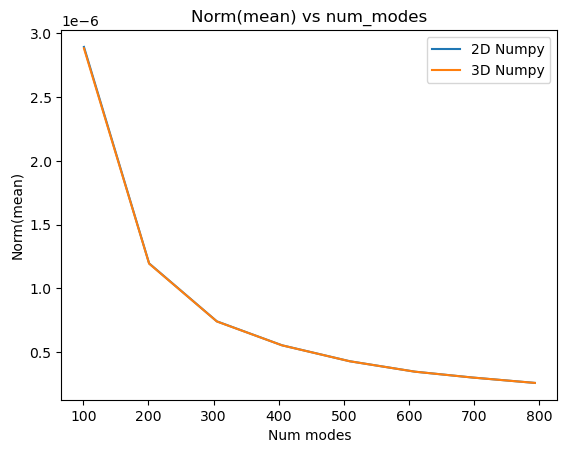

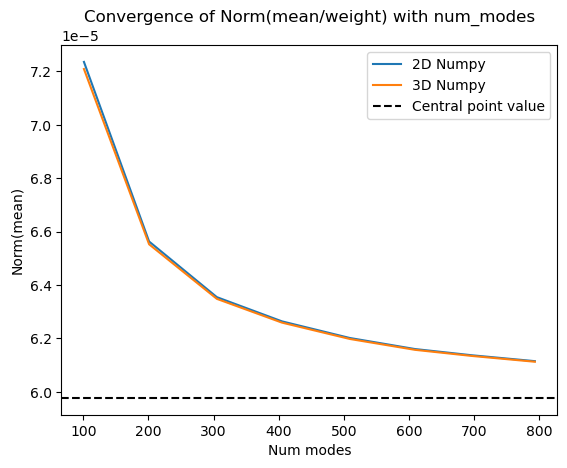

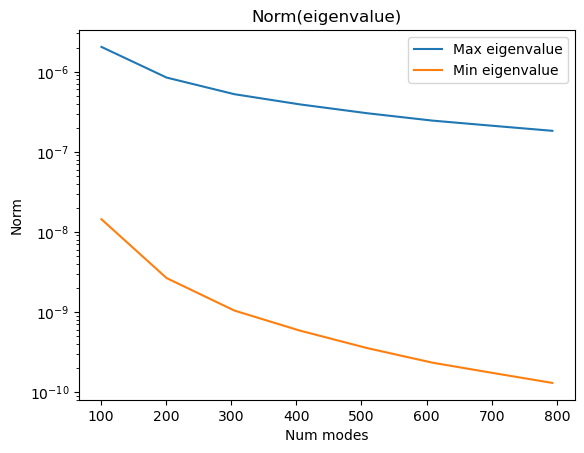

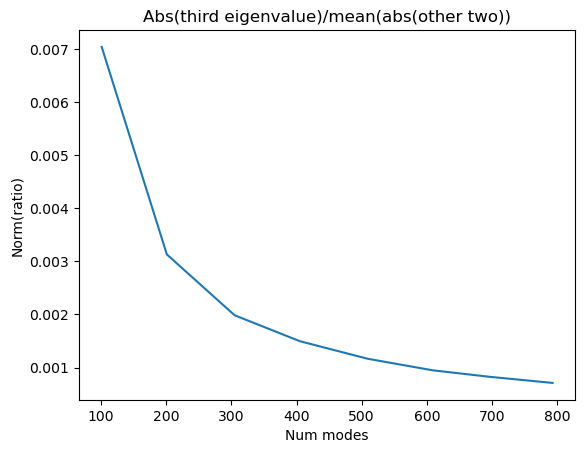

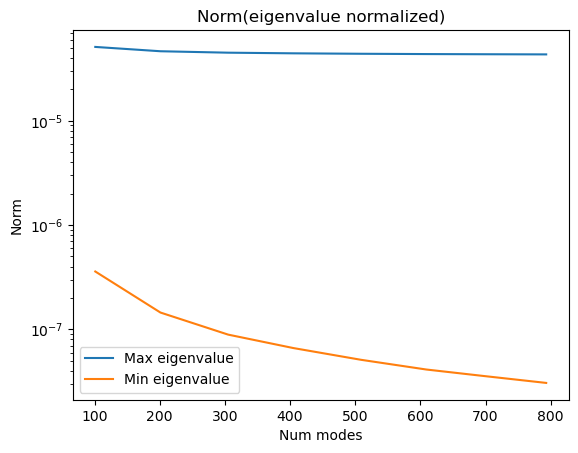

In [18]:
end_index_two = len(central_mean_two_np)
end_index_three = len(central_mean_three_np)

y1 = [np.linalg.norm(mean) for mean in central_mean_two_np]
y2 = [
    np.linalg.norm(mean / mode_grid.by_index(0).weight)
    for mean, mode_grid in zip(
        central_mean_two_np, mode_grids[0:end_index_two]
    )
]

y3 = [np.linalg.norm(mean) for mean in central_mean_three_np]
y4 = [
    np.linalg.norm(mean / mode_grid.by_index(0).weight)
    for mean, mode_grid in zip(
        central_mean_three_np, mode_grids[0:end_index_three]
    )
]


min_vals = [
    np.min(np.abs(np.linalg.eigvals(mat))) for mat in central_mean_three_np
]
max_vals = [
    np.max(np.abs(np.linalg.eigvals(mat))) for mat in central_mean_three_np
]
y5 = np.array(min_vals) / np.array(max_vals)

min_vals_normalized = [
    np.min(np.abs(np.linalg.eigvals(mat / mode_grid.by_index(0).weight)))
    for mat, mode_grid in zip(central_mean_three_np, mode_grids)
]
max_vals_normalized = [
    np.max(np.abs(np.linalg.eigvals(mat / mode_grid.by_index(0).weight)))
    for mat, mode_grid in zip(central_mean_three_np, mode_grids)
]
y6 = np.array(min_vals_normalized) / np.array(max_vals_normalized)


fig, ax = plt.subplots()
ax.plot(np.array(num_modes)[0:end_index_two], y1, label="2D Numpy")
ax.plot(np.array(num_modes)[0:end_index_three], y3, label="3D Numpy")
ax.set_ylabel("Norm(mean)")
ax.set_xlabel("Num modes")
ax.set_title("Norm(mean) vs num_modes")
ax.legend()

fig, ax = plt.subplots()
ax.plot(np.array(num_modes)[0:end_index_two], y2, label="2D Numpy")
ax.plot(np.array(num_modes)[0:end_index_three], y4, label="3D Numpy")
ax.axhline(
    y=ground_truth, color="black", linestyle="--", label="Central point value"
)
ax.set_ylabel("Norm(mean)")
ax.set_xlabel("Num modes")
ax.set_title("Convergence of Norm(mean/weight) with num_modes")
ax.legend()

fig, ax = plt.subplots()
ax.plot(
    np.array(num_modes)[0:end_index_three], max_vals, label="Max eigenvalue"
)
ax.plot(
    np.array(num_modes)[0:end_index_three], min_vals, label="Min eigenvalue"
)
ax.set_ylabel("Norm")
ax.set_xlabel("Num modes")
ax.set_yscale("log")
ax.set_title("Norm(eigenvalue)")
ax.legend()

fig, ax = plt.subplots()
ax.plot(np.array(num_modes)[0:end_index_three], y5, label="3D Numpy")
ax.set_ylabel("Norm(ratio)")
ax.set_xlabel("Num modes")
ax.set_title("Abs(third eigenvalue)/mean(abs(other two))")

fig, ax = plt.subplots()
ax.plot(
    np.array(num_modes)[0:end_index_three],
    max_vals_normalized,
    label="Max eigenvalue",
)
ax.plot(
    np.array(num_modes)[0:end_index_three],
    min_vals_normalized,
    label="Min eigenvalue",
)
ax.set_ylabel("Norm")
ax.set_xlabel("Num modes")
ax.set_yscale("log")
ax.set_title("Norm(eigenvalue normalized)")
ax.legend()